In [3]:
from typing import TypedDict , Literal

In [6]:
class conversion (TypedDict):
    amount_usd : float
    total_usd : float
    total : float
    currency : Literal["INR" , "EUR"]

In [8]:
def total_usd (state : conversion) -> conversion :
    state['total_usd'] = state['amount_usd'] * 1.08
    return state

def cal_to_inr (state:conversion) -> conversion :
    state['total'] = state['total_usd'] * 85
    return state

def cal_to_eur (state:conversion) -> conversion :
    state['total'] = state['total_usd'] * 0.9
    return state

In [10]:
def chosen_condition (state : conversion) -> str :
    return state['currency']

In [16]:
from langgraph.graph import StateGraph , START , END

builder  = StateGraph(conversion)

# adding the nodes 

builder.add_node('cal-total-node' , total_usd)
builder.add_node('cal-to-inr' , cal_to_inr)
builder.add_node('cal_to_eur' , cal_to_eur)

builder.add_edge(START , 'cal-total-node')
builder.add_conditional_edges(
    'cal-total-node' , 
    chosen_condition,
    {
    'INR' : 'cal-to-inr',
    "EUR" : 'cal_to_eur',
    }
)
builder.add_edge (['cal-to-inr', 'cal_to_eur'] , END)

graph = builder.compile()

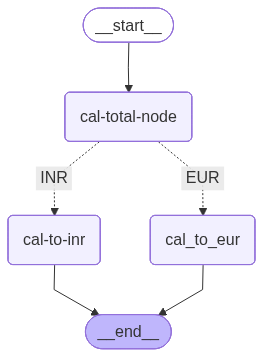

In [17]:
from IPython.display import Image , display

display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
graph.invoke({'amount_usd':1000 , 'currency': 'INR' })

{'amount_usd': 1000, 'total_usd': 1080.0, 'total': 91800.0, 'currency': 'INR'}